# Tutorial 1 · Floating Point & Machine Numbers — Part B (notebook)

**~40 minutes · after the Part A worksheet.**

Everything you just predicted on paper, run live. The rules of this notebook:

1. **Predict before you run.** Each section starts with a question — answer it (out loud, to your partner) *before* executing the cell.
2. Nothing here is graded. Break things. Change the numbers and re-run.

We use only NumPy + Matplotlib (SciPy and PyTorch appear briefly, guarded — the notebook works without them).

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(1)  # seed everything random
np.__version__

'1.26.4'

## 1 · Warm-up: the most famous `False` in programming

**Predict:** what does `0.1 + 0.2 == 0.3` return?

In [2]:
0.1 + 0.2 == 0.3

False

Worksheet Problem 1(b) told you why: $0.1_{10} = 0.0\overline{0011}_2$ repeats forever, so
float64 stores a *rounded impostor* for each of `0.1`, `0.2`, `0.3` — and then rounds the sum
a third time. Print 20 decimal digits and the lie becomes visible:

In [3]:
for label, value in [("0.1      ", 0.1), ("0.2      ", 0.2), ("0.1 + 0.2", 0.1 + 0.2), ("0.3      ", 0.3)]:
    print(f"{label} = {value:.20f}")

0.1       = 0.10000000000000000555
0.2       = 0.20000000000000001110
0.1 + 0.2 = 0.30000000000000004441
0.3       = 0.29999999999999998890


In [4]:
# Decimal shows the *exact* value of the stored float — no formatting tricks:
from decimal import Decimal

print("exact stored 0.1 :", Decimal(0.1))
print("exact stored 0.3 :", Decimal(0.3))
print("gap (0.1+0.2)-0.3:", (0.1 + 0.2) - 0.3)

exact stored 0.1 : 0.1000000000000000055511151231257827021181583404541015625
exact stored 0.3 : 0.299999999999999988897769753748434595763683319091796875
gap (0.1+0.2)-0.3: 5.551115123125783e-17


`0.1 + 0.2` and `0.3` land on **two different points** of the float64 grid, one grid-step apart
($\approx 5.5 \times 10^{-17}$). Neither is wrong by much — they are just not the *same* float.

**Moral for all your future code:** never test floats with `==`; use a tolerance
(`np.isclose`, `math.isclose`).

## 2 · Discover machine epsilon

Worksheet Problem 3: near $1$, floats are spaced by a fixed gap — the **machine epsilon** of
the format. Let's *find* it experimentally: keep halving `eps` until `1 + eps` rounds back
to exactly `1`.

**Predict:** the loop below halves from 1.0. At what power of 2 does it stop for float64?
(float64 has 52 mantissa bits.)

In [5]:
eps = 1.0
while 1.0 + eps / 2 > 1.0:
    eps /= 2

print(f"experimental eps  = {eps}  = 2^{math.log2(eps):.0f}")
print(f"np.finfo(float64) = {np.finfo(np.float64).eps}")

experimental eps  = 2.220446049250313e-16  = 2^-52
np.finfo(float64) = 2.220446049250313e-16


In [6]:
# Same experiment in float32 (23 mantissa bits):
eps32 = np.float32(1.0)
one32 = np.float32(1.0)
while one32 + eps32 / np.float32(2) > one32:
    eps32 /= np.float32(2)

print(f"experimental eps32 = {eps32}  = 2^{math.log2(eps32):.0f}")
print(f"np.finfo(float32)  = {np.finfo(np.float32).eps}")

experimental eps32 = 1.1920928955078125e-07  = 2^-23
np.finfo(float32)  = 1.1920928955078125e-07


$2^{-52} \approx 2.2\times10^{-16}$ for float64, $2^{-23}\approx 1.2\times10^{-7}$ for float32 —
exactly the "one last-mantissa-bit" gap you derived on paper. Float32 carries only
**~7 reliable decimal digits**; float64 carries ~16. Keep those two numbers in your head
forever.

## 3 · The uneven number line

Machine epsilon is the gap **at 1**. The gap *grows with the number* (worksheet Problem 3(c):
gap $= 2^{e-p}$ in $[2^e, 2^{e+1})$). `np.spacing(x)` returns the gap from `x` to the next float.

**Predict:** the spacing at $1$, at $10^6$, and at $10^{16}$ — roughly.

In [7]:
for x in [1.0, 1e6, 1e16]:
    print(f"spacing at {x:>8.0e} : {np.spacing(x):.3e}")

spacing at    1e+00 : 2.220e-16
spacing at    1e+06 : 1.164e-10
spacing at    1e+16 : 2.000e+00


At $10^{16}$ the gap is **2.0** — consecutive representable numbers differ by 2. So adding 1
literally cannot move you to a new float:

In [8]:
x = 1e16
print("x + 1 == x        :", x + 1 == x)          # the 1 is absorbed
print("(x + 1) - x       :", (x + 1) - x)          # worksheet 5(a)
print("(x - x) + 1       :", (x - x) + 1)          # worksheet 5(b): same numbers, other order

x + 1 == x        : True
(x + 1) - x       : 0.0
(x - x) + 1       : 1.0


Same three numbers, different order, different answer: **floating-point addition is not
associative**. This is why summing a million small gradient updates into a large accumulator
is dangerous — and one reason optimizers keep some state in float32 even when training in
half precision.

One picture of the whole number line:

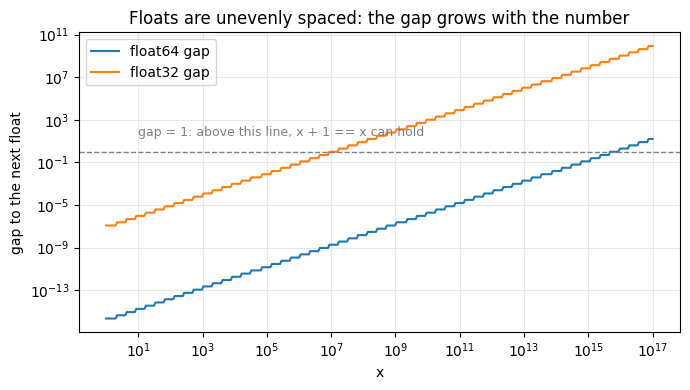

In [9]:
xs = np.logspace(0, 17, 400)

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(xs, np.spacing(xs), label="float64 gap")
ax.loglog(xs, np.spacing(xs.astype(np.float32)).astype(np.float64), label="float32 gap")
ax.axhline(1.0, color="gray", ls="--", lw=1)
ax.annotate("gap = 1: above this line, x + 1 == x can hold",
            xy=(1e1, 1.0), xytext=(1e1, 3e1), fontsize=9, color="gray")
ax.set_xlabel("x")
ax.set_ylabel("gap to the next float")
ax.set_title("Floats are unevenly spaced: the gap grows with the number")
ax.legend()
ax.grid(True, which="major", alpha=0.3)
plt.tight_layout()
plt.show()

Both lines are straight on a log-log plot: the gap is a fixed *fraction* of $x$
($\approx \varepsilon \cdot x$). Float32 crosses gap $=1$ near $2^{23} \approx 8.4\times 10^6$ —
above that, float32 cannot even count integers one by one.

## 4 · Catastrophic cancellation

Subtracting two nearly-equal numbers wipes out their shared leading digits and promotes
rounding noise to the front. Two classic victims:

### 4a · Variance, computed two ways

Both formulas below are *algebraically identical*:

$$\operatorname{Var}(X) = \underbrace{\mathbb{E}[X^2] - \mathbb{E}[X]^2}_{\text{naive: one pass}} = \underbrace{\mathbb{E}\left[(X - \mathbb{E}[X])^2\right]}_{\text{two-pass: subtract the mean first}}$$

Data: 10,000 points with mean $10^9$ and true variance $\approx 1$.

**Predict:** $\mathbb{E}[X^2] \approx 10^{18}$ and $\mathbb{E}[X]^2 \approx 10^{18}$, and we
subtract them hoping to recover a difference of order... 1. What is `np.spacing(1e18)`?

In [10]:
data = 1e9 + rng.standard_normal(10_000)   # mean 1e9, true variance ~1

naive_var = np.mean(data**2) - np.mean(data) ** 2          # E[X^2] - E[X]^2
twopass_var = np.mean((data - np.mean(data)) ** 2)         # E[(X - E[X])^2]

print(f"naive   E[X^2] - E[X]^2 : {naive_var}")
print(f"two-pass                : {twopass_var:.6f}")
print(f"np.var(data) (NumPy)    : {np.var(data):.6f}")
print(f"spacing at 1e18         : {np.spacing(1e18)}")

naive   E[X^2] - E[X]^2 : -128.0
two-pass                : 0.996994
np.var(data) (NumPy)    : 0.996994
spacing at 1e18         : 128.0


The naive formula returns a **negative variance** — mathematically impossible, numerically
routine. Both terms are $\approx 10^{18}$, where the float64 grid steps by
`np.spacing(1e18)` $= 128$; the true difference ($\approx 1$) is *smaller than one grid step*,
so the subtraction returns pure rounding noise. The two-pass formula subtracts the mean
*first*, while the numbers are small, and is perfectly fine.

(If a variance, a norm, or a probability ever comes out negative in your ML code — this is
usually why.)

### 4b · The quadratic formula fails on its own homework

Solve $x^2 - 10^8 x + 1 = 0$. The roots are $\approx 10^8$ and $\approx 10^{-8}$
(their product must be $c/a = 1$).

**Predict:** which root does $\frac{-b - \sqrt{b^2 - 4ac}}{2a}$ get wrong, and why?

In [11]:
a, b, c = 1.0, -1e8, 1.0
disc = math.sqrt(b * b - 4 * a * c)

big_root = (-b + disc) / (2 * a)      # fine: adds two big positives
small_naive = (-b - disc) / (2 * a)   # -b and disc agree to ~16 digits -> cancellation
small_stable = c / (a * big_root)     # stable: product of roots = c/a

print(f"big root              : {big_root}")
print(f"small root, naive     : {small_naive}")
print(f"small root, stable    : {small_stable}")
print(f"true small root       : ~1.0000000000000002e-08")

f = lambda x: x * x + b * x + c        # plug back in: residual check
print(f"\nf(naive)  = {f(small_naive):.4f}   <- not a root at all")
print(f"f(stable) = {f(small_stable):.2e}")

big root              : 100000000.0
small root, naive     : 7.450580596923828e-09
small root, stable    : 1e-08
true small root       : ~1.0000000000000002e-08

f(naive)  = 0.2549   <- not a root at all
f(stable) = 1.11e-16


`-b` and `sqrt(b²-4ac)` agree to about 16 digits, so their difference keeps almost nothing:
the naive small root is off by **25%**, and plugging it back into the polynomial gives a
residual of $0.25$ instead of $\approx 0$. The fix is the same trick as worksheet 5(c):
rewrite to avoid the subtraction (here via the root product $x_1 x_2 = c/a$).

## 5 · Overflow, softmax, and log-sum-exp

Formats have a ceiling: float32 tops out at $\approx 3.4\times10^{38}$, float64 at
$\approx 1.8\times10^{308}$. For $e^x$ that means overflow at $x \approx 88.7$ (float32) and
$x \approx 709.8$ (float64).

**Predict:** `np.exp(89)` in float32 vs float64.

In [12]:
with np.errstate(over="ignore"):
    print("exp(89)  float32 :", np.exp(np.float32(89)))
    print("exp(89)  float64 :", np.exp(np.float64(89)))
    print("exp(710) float64 :", np.exp(np.float64(710)))   # float64's ceiling is ~709.8

exp(89)  float32 : inf
exp(89)  float64 : 4.4896128191743455e+38
exp(710) float64 : inf


Now the ML consequence. Softmax turns scores (logits) into probabilities:
$\operatorname{softmax}(x)_i = e^{x_i} / \sum_j e^{x_j}$. A language model's logits can easily
be in the hundreds. Watch the naive implementation die:

In [13]:
def softmax_naive(x):
    e = np.exp(x)
    return e / e.sum()

def softmax_stable(x):
    e = np.exp(x - np.max(x))   # the max trick: shift so the largest exponent is 0
    return e / e.sum()

logits = np.array([1000.0, 1001.0, 1002.0])

with np.errstate(over="ignore", invalid="ignore"):
    print("naive  :", softmax_naive(logits))
print("stable :", softmax_stable(logits))
print("sums to:", softmax_stable(logits).sum())

naive  : [nan nan nan]
stable : [0.09003057 0.24472847 0.66524096]
sums to: 0.9999999999999999


`inf / inf = nan` — the naive version returns `nan` for *every* class, and one `nan` in a loss
poisons the entire backward pass. The stable version subtracts the max first
(worksheet Problem 6): softmax is shift-invariant, so the answer is identical, but the largest
shifted exponent is $e^0 = 1$ — overflow is impossible.

The same trick computes $\log \sum_i e^{x_i}$ — the log-sum-exp at the heart of cross-entropy
loss. Libraries ship it ready-made:

In [14]:
def logsumexp_by_hand(x):
    m = np.max(x)
    return m + np.log(np.sum(np.exp(x - m)))

print("by hand          :", logsumexp_by_hand(np.array([1000.0, 1000.0, 1000.0])))
print("worksheet answer : 1000 + ln(3) =", 1000 + math.log(3))

try:
    from scipy.special import logsumexp
    print("scipy.special    :", logsumexp([1000.0, 1000.0, 1000.0]))
except ImportError:
    print("scipy not installed — skipping (the by-hand version above is the same thing)")

by hand          : 1001.0986122886682
worksheet answer : 1000 + ln(3) = 1001.0986122886682
scipy.special    : 1001.0986122886682


## 6 · dtype tour: float16 vs bfloat16

Deep learning rarely trains in float64 — memory and speed push it to 16 bits. There are two
ways to spend 16 bits, and they make opposite trade-offs:

| format | sign | exponent | mantissa | max value | decimal digits |
|---|---|---|---|---|---|
| float16 | 1 | 5 | 10 | 65,504 | ~3 |
| bfloat16 | 1 | 8 | 7 | $\approx 3.4\times10^{38}$ | ~2 |

bfloat16 keeps **float32's exponent** (same range, so gradients don't overflow/underflow)
and pays with precision. float16 does the reverse.

**Predict:** what happens to $10^5$ in each format?

In [15]:
# bfloat16 backend: prefer ml_dtypes, fall back to torch, else skip gracefully.
bf16_cast = None
try:
    import ml_dtypes
    bf16_cast = lambda v: float(np.asarray(v, dtype=ml_dtypes.bfloat16))
    print("bfloat16 backend: ml_dtypes")
except ImportError:
    try:
        import torch
        bf16_cast = lambda v: torch.tensor(v, dtype=torch.bfloat16).item()
        print("bfloat16 backend: torch")
    except ImportError:
        print("Neither ml_dtypes nor torch available — bfloat16 column will be skipped.")

bfloat16 backend: torch


In [16]:
values = [1e5, 3.14159265, 1.001]

header = f"{'value':>12} | {'float16':>12}"
if bf16_cast is not None:
    header += f" | {'bfloat16':>12}"
print(header)
print("-" * len(header))
for v in values:
    row = f"{v:>12} | {float(np.float16(v)):>12}"
    if bf16_cast is not None:
        row += f" | {bf16_cast(v):>12}"
    print(row)

       value |      float16 |     bfloat16
------------------------------------------
    100000.0 |          inf |      99840.0
  3.14159265 |     3.140625 |     3.140625
       1.001 | 1.0009765625 |          1.0


/var/folders/1x/wmgn24mn1bbd2vgbqlk98tbc0000gn/T/ipykernel_33336/670532066.py:9: RuntimeWarning: overflow encountered in cast
  row = f"{v:>12} | {float(np.float16(v)):>12}"


Reading the table:

- $10^5$ **overflows float16 to `inf`** (its max is 65,504) but is finite in bfloat16 —
  merely rounded to a nearby representable value. Range vs precision, exactly as designed.
- $\pi$ keeps ~3 correct digits in float16, ~2 in bfloat16.
- $1.001$: bfloat16's gap at 1 is $2^{-7} \approx 0.008$, so the $0.001$ may vanish entirely.

If neither `ml_dtypes` nor `torch` was available above, the bfloat16 column is skipped —
the table row for float16 still shows the overflow, and the trade-off table in the markdown
tells the bfloat16 half of the story.

## 7 · Closing

Three things to take out of this tutorial:

- **Floats are a finite, unevenly spaced grid** — the gap grows in proportion to the number
  (relative grain: $2^{-24}$ for float32, $2^{-53}$ for float64). "The computer stores 0.1"
  is already an approximation.
- **Every single operation rounds correctly; disasters are correct roundings arranged badly.**
  The three failure patterns you can now recognize on sight: *absorption* (`1e16 + 1`),
  *catastrophic cancellation* (naive variance, quadratic formula), *overflow/underflow of
  intermediates* (naive softmax).
- **The fixes are algebra, not more bits.** Conjugate rewrites, subtracting the mean first,
  the log-sum-exp max trick — the same mathematical value computed along a path that stays on
  friendly parts of the grid.

**What this means for AI:**

- **Modern models train in bfloat16 / mixed precision.** bfloat16 exists precisely because
  gradient *range* matters more than gradient *precision*; optimizers still keep master
  weights and accumulators in float32 because a million tiny updates into a big accumulator
  is Section 3's absorption problem.
- **Language models live in log-space.** A sentence's probability is a product of thousands of
  numbers $< 1$ — guaranteed underflow — so every framework works with log-probabilities and
  cross-entropy is computed with the log-sum-exp trick from Section 5. When we build our
  character-level language model in the final lecture, this is the machinery keeping it alive.
- **When a training loss goes `NaN`** (Lecture 2's opening demo), you now have the suspect
  list: an `exp` that overflowed, a cancellation that went negative inside a `sqrt`/`log`, a
  division by an absorbed-to-zero denominator.

*Computers don't do real numbers — they do ~4 billion of them, unevenly spaced.*